In [1]:
import sys
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
sys.path.insert(0, '..')
from FAR.utils.read import Merge
from FAR.utils.predict import RankStat

In [2]:
path = '/data/gravwav/lopezm/Projects/GlitchBank/'
path_store = path + 'runs/background/results/'
timeslides_file = 'computational-aspects-of-machine-learning-project-3/FAR/timeslides_1132.9y.csv'
ifos = ['H1L1', 'H1V1', 'L1V1', 'H1L1V1']
catalog = pd.read_pickle('/data/gravwav/lopezm/Projects/GlitchBank/runs/known_catalogs.csv')
path_zero_lag = '/data/gravwav/lopezm/Projects/GlitchBank/runs/zero_lag/'
merge = Merge(path_store, path + timeslides_file)
ifo = ifos[0]

In [39]:
t_bkg, bkg = merge.mergeTriggers(ifo)

In [40]:
file = f'triggers{ifo.replace("1", "")}_zero_lag_eq_match.csv'
tmp = pd.read_csv(path_zero_lag+file)

In [41]:
formula = 1
bkg_ = RankStat(bkg.copy(), ifo, formula)
tmp_ = RankStat(tmp.copy(), ifo, formula)

In [83]:
tmp['']

Index(['Unnamed: 0', 'feature_H1', 'Num triggers_H1', 'Cluster ID_H1',
       'Cluster time_H1', 'Cluster idx_H1', 'Prob_0_H1', 'Prob_1_H1',
       'Prob_2_H1', 'Prob_3_H1', 'Prob_4_H1', 'Prob_5_H1', 'Prob_6_H1',
       'Pinj_H1', 'rank_stat_H1', 'ifo_max_H1', 'SNR_max_H1', 'Chisq_max_H1',
       'Trigger ID_max_H1', 'Template ID_max_H1', 'Trigger time_max_H1',
       'Mass_1_max_H1', 'Mass_2_max_H1', 'Spin1z_max_H1', 'Spin2z_max_H1',
       'Cluster time old_H1', 'Cluster idx_H1.1', 'feature_L1',
       'Num triggers_L1', 'Cluster ID_L1', 'Cluster time_L1', 'Cluster idx_L1',
       'Prob_0_L1', 'Prob_1_L1', 'Prob_2_L1', 'Prob_3_L1', 'Prob_4_L1',
       'Prob_5_L1', 'Prob_6_L1', 'Pinj_L1', 'rank_stat_L1', 'ifo_max_L1',
       'SNR_max_L1', 'Chisq_max_L1', 'Trigger ID_max_L1', 'Template ID_max_L1',
       'Trigger time_max_L1', 'Mass_1_max_L1', 'Mass_2_max_L1',
       'Spin1z_max_L1', 'Spin2z_max_L1', 'Cluster time old_L1',
       'Cluster idx_L1.1', 'barPinj', 'rank_stat_H1L1'],
      

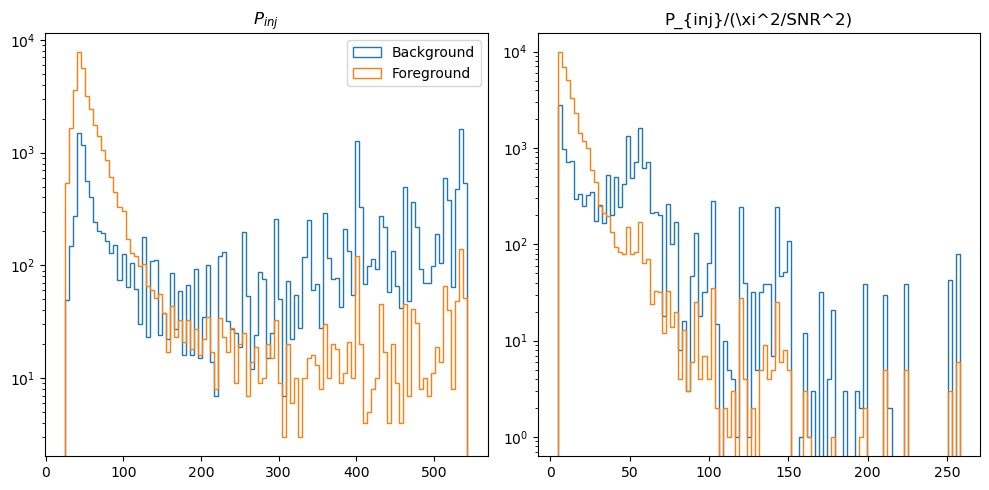

In [87]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
# First subplot
ax1.hist(bkg['Mass_1_max_H1'], density=False, bins=100, histtype='step', label='Background')
ax1.hist(tmp['Mass_1_max_H1'], density=False, bins=100, histtype='step', label='Foreground')
#ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_title(r'$P_{inj}$')

ax1.legend()

# Second subplot
ax2.hist(bkg['Mass_2_max_H1'], density=False, bins=100, histtype='step', label='Background')
ax2.hist(tmp['Mass_2_max_H1'], density=False, bins=100, histtype='step', label='Foreground')
# ax2.set_xscale('log') # Commented out as per instruction
ax2.set_yscale('log')
#ax2.set_xscale('log')
ax2.set_title(r'P_{inj}/(\xi^2/SNR^2)')

# Show plot
plt.tight_layout()
plt.show()

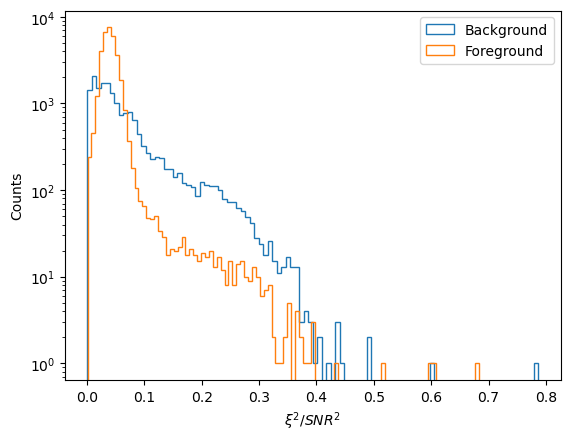

In [117]:
plt.hist(bkg_['Chisq_max_L1']/bkg_['SNR_max_L1']**2, bins=100, histtype='step', label='Background')
plt.hist(tmp_['Chisq_max_L1']/tmp_['SNR_max_L1']**2, bins=100, histtype='step', label='Foreground')
plt.yscale('log')
plt.xlabel(r'$\xi^2/SNR^2$')
plt.ylabel('Counts')
plt.legend()

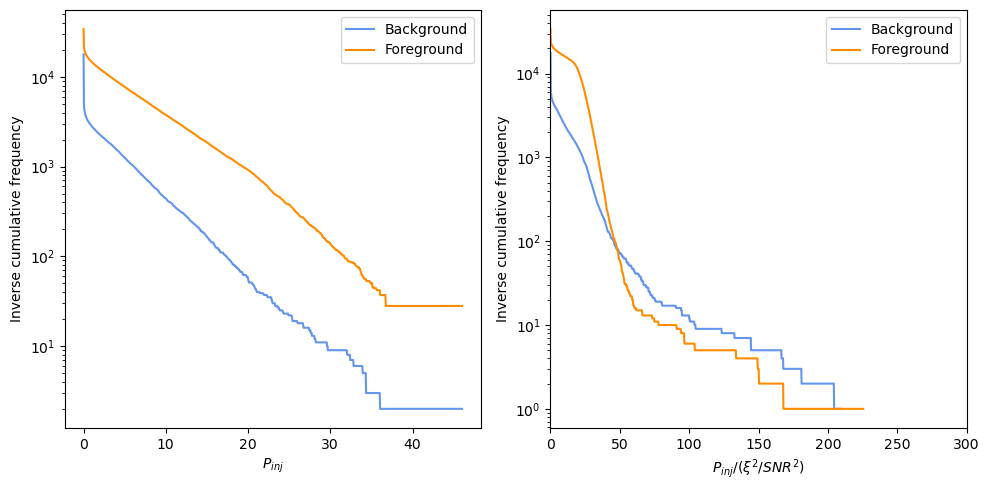

In [82]:
def plot_inverse_cumulative_histogram(data, bins=10):
    # Compute the histogram
    counts, bin_edges = np.histogram(data, bins=bins)
    
    # Compute the cumulative sum of the counts in reverse order
    inverse_cumulative_counts = np.cumsum(counts[::-1])[::-1]

    return bin_edges, inverse_cumulative_counts

formula=1


b1, ib1 = plot_inverse_cumulative_histogram(bkg['rank_stat_'+ifo], bins=1000)
b2, ib2 = plot_inverse_cumulative_histogram(bkg_['rank_stat_'+ifo], bins=1000)
z1, iz1 = plot_inverse_cumulative_histogram(tmp['rank_stat_'+ifo], bins=1000)
z2, iz2 = plot_inverse_cumulative_histogram(tmp_['rank_stat_'+ifo], bins=1000)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
# First subplot
ax1.plot(b1[:-1], ib1, color='cornflowerblue', label='Background')
ax1.plot(z1[:-1], iz1, color='darkorange', label='Foreground')
#ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel(r'$P_{inj}$'), ax1.set_ylabel('Inverse cumulative frequency')
ax1.legend()

# Second subplot
ax2.plot(b2[:-1], ib2, color='cornflowerblue', label='Background')
ax2.plot(z2[:-1], iz2, color='darkorange', label='Foreground')
# ax2.set_xscale('log') # Commented out as per instruction
ax2.set_yscale('log')
#ax2.set_xscale('log')
ax2.set_xlim(0, 300)
ax2.set_xlabel(r'$P_{inj}/(\xi^2/SNR^2)$'), ax2.set_ylabel('Inverse cumulative frequency')
ax2.legend()
# Show plot
plt.tight_layout()
plt.show()
